In [ ]:
import re
from pathlib import Path
import pandas as pd

# =========================================================
# 1) INPUT / OUTPUT
# =========================================================
INPUT_FILES = [
    "/content/train.csv",
    "/content/validation.csv",
    "/content/test.csv",
]

OUTPUT_DIR = Path("/content/hssc_title_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2) FIXED TITLE SIGNAL RULES
# =========================================================
QUESTION_SIGNAL_PATTERNS = [
    r"\bvai\b",
    r"\btiešām\b",
    r"\btaisnība\b",
]

NEGATION_SIGNAL_PATTERNS = [
    r"\bnav\b",
    r"\bnē\b",
    r"\bpierādījum\w*\b",
    r"\bmelo\b",
    r"\bmeli\b",
    r"\bmaldin\w*\b",
    r"\bnepaties\w*\b",
    r"\bneizraisa\b",
    r"\bnevar\b",
    r"\bnebija\b",
]

TOPIC_SIGNAL_PATTERNS = [
    r"\bcovid\b",
    r"\bvakcīn\w*\b",
    r"\bpotes\b",
    r"\bkremļa\b",
    r"\bputina\b",
    r"\bķīmisk\w*\b",
    r"\btrases\b",
    r"\bvēj\w*\b",
    r"\bturbīn\w*\b",
    r"\bpvo\b",
    r"\bnato\b",
    r"\bvideo\b",
    r"\bmi\b",
]

QUESTION_SIGNAL_REGEX = re.compile(
    "|".join(QUESTION_SIGNAL_PATTERNS),
    flags=re.IGNORECASE | re.UNICODE
)

NEGATION_SIGNAL_REGEX = re.compile(
    "|".join(NEGATION_SIGNAL_PATTERNS),
    flags=re.IGNORECASE | re.UNICODE
)

TOPIC_SIGNAL_REGEX = re.compile(
    "|".join(TOPIC_SIGNAL_PATTERNS),
    flags=re.IGNORECASE | re.UNICODE
)

WORD_REGEX = re.compile(r"\b\w+\b", flags=re.UNICODE)
CAPS_REGEX = re.compile(r"\b[A-ZĀČĒĢĪĶĻŅŠŪŽ]{2,}\b", flags=re.UNICODE)

# =========================================================
# 3) CLEANING
# =========================================================
def clean_title(text: object) -> str:
    if pd.isna(text):
        return ""
    text = str(text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text)

    # strip outer spaces
    text = text.strip()

    return text


def safe_divide(a: float, b: float) -> float:
    return a / b if b != 0 else 0.0


# =========================================================
# 4) FEATURE EXTRACTION
# =========================================================
def extract_title_features(title: str) -> dict:
    t = clean_title(title)
    lower_t = t.lower()

    words = WORD_REGEX.findall(t)
    word_count = len(words)
    char_count = len(t)

    exclamation_count = t.count("!")
    question_count = t.count("?")

    has_exclamation = int(exclamation_count > 0)
    has_question_mark = int(question_count > 0)
    has_quotes = int(('"' in t) or ("“" in t) or ("”" in t) or ("'" in t))
    has_number = int(bool(re.search(r"\d", t)))

    caps_words = CAPS_REGEX.findall(t)
    caps_count = len(caps_words)
    has_caps = int(caps_count > 0)
    uppercase_ratio = safe_divide(caps_count, word_count)

    has_question_signal = int(bool(QUESTION_SIGNAL_REGEX.search(lower_t)))
    has_negation_signal = int(bool(NEGATION_SIGNAL_REGEX.search(lower_t)))
    has_topic_signal = int(bool(TOPIC_SIGNAL_REGEX.search(lower_t)))

    signal_group_count = (
        has_question_signal +
        has_negation_signal +
        has_topic_signal
    )

    has_any_signal = int(signal_group_count >= 1)
    has_multi_signal = int(signal_group_count >= 2)
    has_all_three_signals = int(signal_group_count == 3)

    short_title_flag = int(3 <= word_count <= 8)

    title_signal_score = (
        0.25 * has_question_signal +
        0.23 * has_negation_signal +
        0.20 * has_topic_signal +
        0.22 * has_question_mark +
        0.22 * has_multi_signal +
        0.10 * has_all_three_signals +
        0.05 * has_quotes +
        0.04 * short_title_flag +
        0.03 * has_exclamation -
        0.05 * has_number -
        0.05 * has_caps -
        0.03 * min(uppercase_ratio * 3, 1.0)
    )

    title_signal_score = max(float(title_signal_score), 0.0)

    return {
        "title_clean": t,
        "title_len_chars": char_count,
        "title_len_words": word_count,
        "has_exclamation": has_exclamation,
        "has_question_mark": has_question_mark,
        "has_quotes": has_quotes,
        "has_number": has_number,
        "has_caps": has_caps,
        "caps_count": caps_count,
        "uppercase_ratio": uppercase_ratio,
        "has_question_signal": has_question_signal,
        "has_negation_signal": has_negation_signal,
        "has_topic_signal": has_topic_signal,
        "has_any_signal": has_any_signal,
        "has_multi_signal": has_multi_signal,
        "has_all_three_signals": has_all_three_signals,
        "short_title_flag": short_title_flag,
        "title_signal_score": title_signal_score,
    }


# =========================================================
# 5) PROCESS FILES
# =========================================================
def process_file(input_file: str):
    path = Path(input_file)
    df = pd.read_csv(path, encoding="utf-8")

    if "title" not in df.columns:
        raise ValueError(f"Missing 'title' column in {path.name}")

    df["title"] = df["title"].fillna("").astype(str)

    feature_df = df["title"].apply(extract_title_features).apply(pd.Series)
    out_df = pd.concat([df, feature_df], axis=1)

    output_file = OUTPUT_DIR / f"{path.stem}_title_features.csv"
    out_df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"Processed: {path.name}")
    print(f"Saved: {output_file}")
    print(f"Rows: {len(out_df)}")
    print()


for input_file in INPUT_FILES:
    process_file(input_file)

Processed: train.csv
Saved: /content/hssc_title_features/train_title_features.csv
Rows: 1429

Processed: validation.csv
Saved: /content/hssc_title_features/validation_title_features.csv
Rows: 306

Processed: test.csv
Saved: /content/hssc_title_features/test_title_features.csv
Rows: 307



# text signal **builder**

Šis ir production-ready text signal builder. Tas:
	1.	ielādē train, validation, test,
	2.	attīra full_text,
	3.	izvelk fiksētās text signal features,
	4.	aprēķina text_signal_score,
	5.	saglabā jaunus failus ar pievienotām text signal kolonnām.

Tas ir feature engineering, nevis HSSC modelis.

In [ ]:
import re
from pathlib import Path
import pandas as pd

# =========================================================
# 1) INPUT / OUTPUT
# =========================================================
INPUT_FILES = [
    "/content/train.csv",
    "/content/validation.csv",
    "/content/test.csv",
]

OUTPUT_DIR = Path("/content/hssc_text_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2) FIXED TEXT SIGNAL RULES
# =========================================================
DEBUNKING_SIGNAL_PATTERNS = [
    r"\bmaldi\b",
    r"\bmaldus\b",
    r"\bmaldin\w*\b",
    r"\bnepaties\w*\b",
    r"\bmelo\b",
    r"\bmeli\b",
    r"\bnav\s+taisnība\b",
    r"\bpierādījum\w*\b",
    r"\batmasko\w*\b",
]

SOURCE_REFERENCE_SIGNAL_PATTERNS = [
    r"\bierakst\w*\b",
    r"\bekrānuzņēm\w*\b",
    r"\bkomentār\w*\b",
    r"\bpublikāc\w*\b",
    r"\brakst\w*\b",
    r"\bvideo\b",
    r"\bdalījušies\b",
    r"\bpausts\b",
]

TOPIC_SIGNAL_PATTERNS = [
    r"\bcovid\b",
    r"\bvakcīn\w*\b",
    r"\bvakcin\w*\b",
    r"\bpotes\b",
    r"\bpfizer\b",
    r"\bmrns\b",
    r"\bsputnik\b",
    r"\bkremļa\b",
    r"\bputina\b",
    r"\bķīmisk\w*\b",
    r"\bpvo\b",
]

DEBUNKING_SIGNAL_REGEX = re.compile(
    "|".join(DEBUNKING_SIGNAL_PATTERNS),
    flags=re.IGNORECASE | re.UNICODE
)

SOURCE_REFERENCE_SIGNAL_REGEX = re.compile(
    "|".join(SOURCE_REFERENCE_SIGNAL_PATTERNS),
    flags=re.IGNORECASE | re.UNICODE
)

TOPIC_SIGNAL_REGEX = re.compile(
    "|".join(TOPIC_SIGNAL_PATTERNS),
    flags=re.IGNORECASE | re.UNICODE
)

WORD_REGEX = re.compile(r"\b\w+\b", flags=re.UNICODE)

# =========================================================
# 3) CLEANING
# =========================================================
def clean_full_text(text: object) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


def safe_divide(a: float, b: float) -> float:
    return a / b if b != 0 else 0.0


# =========================================================
# 4) FEATURE EXTRACTION
# =========================================================
def extract_text_features(text: str) -> dict:
    t = clean_full_text(text)
    lower_t = t.lower()

    words = WORD_REGEX.findall(t)
    word_count = len(words)
    char_count = len(t)

    has_debunking_signal = int(bool(DEBUNKING_SIGNAL_REGEX.search(lower_t)))
    has_source_reference_signal = int(bool(SOURCE_REFERENCE_SIGNAL_REGEX.search(lower_t)))
    has_topic_signal_text = int(bool(TOPIC_SIGNAL_REGEX.search(lower_t)))

    debunking_matches = len(DEBUNKING_SIGNAL_REGEX.findall(lower_t))
    source_reference_matches = len(SOURCE_REFERENCE_SIGNAL_REGEX.findall(lower_t))
    topic_matches = len(TOPIC_SIGNAL_REGEX.findall(lower_t))

    signal_group_count = (
        has_debunking_signal +
        has_source_reference_signal +
        has_topic_signal_text
    )

    has_any_text_signal = int(signal_group_count >= 1)
    has_multi_text_signal = int(signal_group_count >= 2)
    has_all_three_text_signals = int(signal_group_count == 3)

    signal_match_total = (
        debunking_matches +
        source_reference_matches +
        topic_matches
    )

    signal_density = safe_divide(signal_match_total, word_count)

    # simple composite score for text signals
    text_signal_score = (
        0.30 * has_debunking_signal +
        0.28 * has_source_reference_signal +
        0.22 * has_topic_signal_text +
        0.15 * has_multi_text_signal +
        0.10 * has_all_three_text_signals +
        0.20 * min(signal_density * 50, 1.0)
    )

    text_signal_score = max(float(text_signal_score), 0.0)

    return {
        "full_text_clean": t,
        "text_len_chars": char_count,
        "text_len_words": word_count,
        "has_debunking_signal": has_debunking_signal,
        "has_source_reference_signal": has_source_reference_signal,
        "has_topic_signal_text": has_topic_signal_text,
        "has_any_text_signal": has_any_text_signal,
        "has_multi_text_signal": has_multi_text_signal,
        "has_all_three_text_signals": has_all_three_text_signals,
        "debunking_match_count": debunking_matches,
        "source_reference_match_count": source_reference_matches,
        "topic_match_count": topic_matches,
        "signal_match_total": signal_match_total,
        "signal_density": signal_density,
        "text_signal_score": text_signal_score,
    }


# =========================================================
# 5) PROCESS FILES
# =========================================================
def process_file(input_file: str):
    path = Path(input_file)
    df = pd.read_csv(path, encoding="utf-8")

    if "full_text" not in df.columns:
        raise ValueError(f"Missing 'full_text' column in {path.name}")

    df["full_text"] = df["full_text"].fillna("").astype(str)

    feature_df = df["full_text"].apply(extract_text_features).apply(pd.Series)
    out_df = pd.concat([df, feature_df], axis=1)

    output_file = OUTPUT_DIR / f"{path.stem}_text_features.csv"
    out_df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"Processed: {path.name}")
    print(f"Saved: {output_file}")
    print(f"Rows: {len(out_df)}")
    print()


for input_file in INPUT_FILES:
    process_file(input_file)

Processed: train.csv
Saved: /content/hssc_text_features/train_text_features.csv
Rows: 1429

Processed: validation.csv
Saved: /content/hssc_text_features/validation_text_features.csv
Rows: 306

Processed: test.csv
Saved: /content/hssc_text_features/test_text_features.csv
Rows: 307



saskaņot title + text features vienā failā,

	1.	ielādē attiecīgo title_features failu,
	2.	ielādē attiecīgo text_features failu,
	3.	pārbauda, ka rindu skaits sakrīt,
	4.	paņem bāzes kolonnas tikai vienu reizi,
	5.	pievieno title feature kolonnas,
	6.	pievieno text feature kolonnas,
	7.	saglabā vienotu feature failu katram splitam.

Tas ir tikai feature merge, lai nākamajā solī var pievienot semantic signālu no LVBERT.

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# 1) INPUT / OUTPUT PATHS
# =========================================================
TITLE_DIR = Path("/content/hssc_title_features")
TEXT_DIR = Path("/content/hssc_text_features")
OUTPUT_DIR = Path("/content/hssc_merged_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "validation", "test"]

BASE_COLUMNS = ["title", "full_text", "class_label"]

TITLE_FEATURE_COLUMNS = [
    "title_clean",
    "title_len_chars",
    "title_len_words",
    "has_exclamation",
    "has_question_mark",
    "has_quotes",
    "has_number",
    "has_caps",
    "caps_count",
    "uppercase_ratio",
    "has_question_signal",
    "has_negation_signal",
    "has_topic_signal",
    "has_any_signal",
    "has_multi_signal",
    "has_all_three_signals",
    "short_title_flag",
    "title_signal_score",
]

TEXT_FEATURE_COLUMNS = [
    "full_text_clean",
    "text_len_chars",
    "text_len_words",
    "has_debunking_signal",
    "has_source_reference_signal",
    "has_topic_signal_text",
    "has_any_text_signal",
    "has_multi_text_signal",
    "has_all_three_text_signals",
    "debunking_match_count",
    "source_reference_match_count",
    "topic_match_count",
    "signal_match_total",
    "signal_density",
    "text_signal_score",
]

# =========================================================
# 2) MERGE FUNCTION
# =========================================================
def merge_split_features(split_name: str):
    title_file = TITLE_DIR / f"{split_name}_title_features.csv"
    text_file = TEXT_DIR / f"{split_name}_text_features.csv"

    title_df = pd.read_csv(title_file, encoding="utf-8")
    text_df = pd.read_csv(text_file, encoding="utf-8")

    if len(title_df) != len(text_df):
        raise ValueError(
            f"Row count mismatch for {split_name}: "
            f"title={len(title_df)} vs text={len(text_df)}"
        )

    # base columns only once
    merged_df = title_df[BASE_COLUMNS].copy()

    # add title features
    merged_df = pd.concat(
        [merged_df, title_df[TITLE_FEATURE_COLUMNS].copy()],
        axis=1
    )

    # add text features
    merged_df = pd.concat(
        [merged_df, text_df[TEXT_FEATURE_COLUMNS].copy()],
        axis=1
    )

    output_file = OUTPUT_DIR / f"{split_name}_merged_features.csv"
    merged_df.to_csv(output_file, index=False, encoding="utf-8")

    print(f"Processed: {split_name}")
    print(f"Saved: {output_file}")
    print(f"Rows: {len(merged_df)}")
    print(f"Columns: {len(merged_df.columns)}")
    print()

# =========================================================
# 3) RUN ALL
# =========================================================
for split in SPLITS:
    merge_split_features(split)

Processed: train
Saved: /content/hssc_merged_features/train_merged_features.csv
Rows: 1429
Columns: 36

Processed: validation
Saved: /content/hssc_merged_features/validation_merged_features.csv
Rows: 306
Columns: 36

Processed: test
Saved: /content/hssc_merged_features/test_merged_features.csv
Rows: 307
Columns: 36



# pievienot LVBERT semantic signal (pred_prob)**bold text**

Šis solis:
	1.	ielādē jau apvienotos title + text feature failus,
	2.	ielādē LVBERT prediction failus katram splitam,
	3.	pārbauda, ka rindu skaits sakrīt,
	4.	pievieno semantisko signālu pred_prob kā jaunu kolonnu,
	5.	saglabā gala HSSC input failus.

Šis ir final HSSC feature merge:
	1.	ielādē merged handcrafted features,
	2.	ielādē LVBERT prediction failus,
	3.	pārbauda, vai rindu skaits sakrīt,
	4.	pievieno semantic_signal,
	5.	saglabā gala feature failus, kurus izmantosi HSSC training notebookā.

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# PATHS
# =========================================================
MERGED_DIR = Path("/content/hssc_merged_features")
OUTPUT_DIR = Path("/content/hssc_final_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MERGED_FILES = {
    "train": MERGED_DIR / "train_merged_features.csv",
    "validation": MERGED_DIR / "validation_merged_features.csv",
    "test": MERGED_DIR / "test_merged_features.csv",
}

TRAINVAL_OOF_FILE = "/content/trainval_oof_predictions.csv"
TEST_PRED_FILE = "/content/lvbert_test_predictions.csv"

# =========================================================
# LOAD LVBERT PREDICTIONS
# =========================================================
trainval_oof_df = pd.read_csv(TRAINVAL_OOF_FILE, encoding="utf-8")
test_pred_df = pd.read_csv(TEST_PRED_FILE, encoding="utf-8")

if "pred_prob" not in trainval_oof_df.columns:
    raise ValueError("'pred_prob' not found in trainval_oof_predictions.csv")

if "pred_prob" not in test_pred_df.columns:
    raise ValueError("'pred_prob' not found in lvbert_test_predictions.csv")

# =========================================================
# SPLIT TRAINVAL OOF BACK INTO TRAIN / VALIDATION
# =========================================================
train_merged_df = pd.read_csv(MERGED_FILES["train"], encoding="utf-8")
val_merged_df = pd.read_csv(MERGED_FILES["validation"], encoding="utf-8")
test_merged_df = pd.read_csv(MERGED_FILES["test"], encoding="utf-8")

n_train = len(train_merged_df)
n_val = len(val_merged_df)
n_test = len(test_merged_df)

if len(trainval_oof_df) != n_train + n_val:
    raise ValueError(
        f"Row mismatch in train+validation OOF file: "
        f"{len(trainval_oof_df)} vs expected {n_train + n_val}"
    )

if len(test_pred_df) != n_test:
    raise ValueError(
        f"Row mismatch in test prediction file: "
        f"{len(test_pred_df)} vs expected {n_test}"
    )

train_oof_df = trainval_oof_df.iloc[:n_train].reset_index(drop=True)
val_oof_df = trainval_oof_df.iloc[n_train:n_train + n_val].reset_index(drop=True)

# =========================================================
# FUNCTION
# =========================================================
def append_semantic_signal(merged_df, pred_df, split_name):
    if len(merged_df) != len(pred_df):
        raise ValueError(
            f"Row mismatch in {split_name}: {len(merged_df)} vs {len(pred_df)}"
        )

    out_df = merged_df.copy()
    out_df["semantic_signal"] = pred_df["pred_prob"].astype(float)

    output_path = OUTPUT_DIR / f"{split_name}_hssc_features.csv"
    out_df.to_csv(output_path, index=False, encoding="utf-8")

    print(f"Processed: {split_name}")
    print(f"Saved: {output_path}")
    print(f"Rows: {len(out_df)}")
    print(f"Semantic range: {out_df['semantic_signal'].min():.6f} - {out_df['semantic_signal'].max():.6f}")
    print()

# =========================================================
# RUN
# =========================================================
append_semantic_signal(train_merged_df, train_oof_df, "train")
append_semantic_signal(val_merged_df, val_oof_df, "validation")
append_semantic_signal(test_merged_df, test_pred_df, "test")

Processed: train
Saved: /content/hssc_final_features/train_hssc_features.csv
Rows: 1429
Semantic range: 0.000139 - 0.999790

Processed: validation
Saved: /content/hssc_final_features/validation_hssc_features.csv
Rows: 306
Semantic range: 0.000147 - 0.999791

Processed: test
Saved: /content/hssc_final_features/test_hssc_features.csv
Rows: 307
Semantic range: 0.000104 - 0.999828



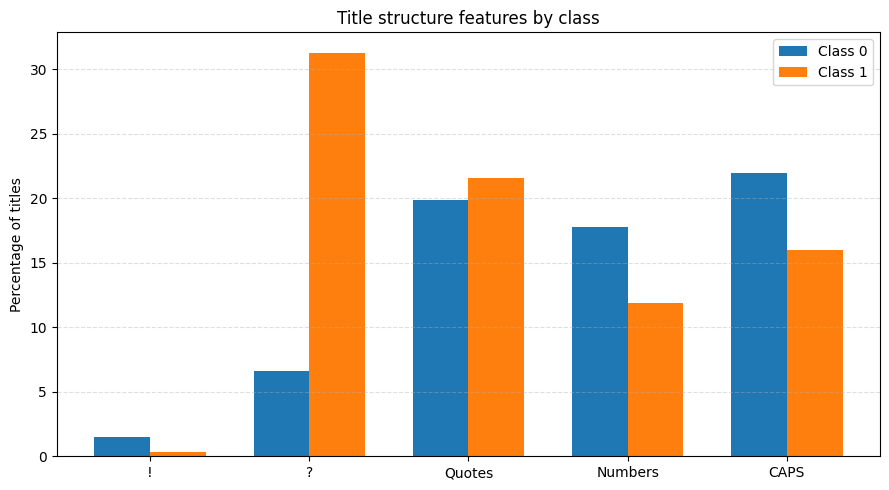

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------
# DATA
# ---------------------------------------
features = ["!", "?", "Quotes", "Numbers", "CAPS"]

class0 = [1.533, 6.583, 19.838, 17.764, 22.002]
class1 = [0.313, 31.315, 21.608, 11.900, 15.971]

x = np.arange(len(features))
width = 0.35

# ---------------------------------------
# PLOT
# ---------------------------------------
plt.figure(figsize=(9, 5))

plt.bar(x - width/2, class0, width, label="Class 0")
plt.bar(x + width/2, class1, width, label="Class 1")

plt.xticks(x, features)
plt.ylabel("Percentage of titles")
plt.title("Title structure features by class")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

test_df = pd.read_csv("/content/hssc_final_features/test_hssc_features.csv")

print(test_df.columns)
print(len(test_df))

Index(['title', 'full_text', 'class_label', 'title_clean', 'title_len_chars',
       'title_len_words', 'has_exclamation', 'has_question_mark', 'has_quotes',
       'has_number', 'has_caps', 'caps_count', 'uppercase_ratio',
       'has_question_signal', 'has_negation_signal', 'has_topic_signal',
       'has_any_signal', 'has_multi_signal', 'has_all_three_signals',
       'short_title_flag', 'title_signal_score', 'full_text_clean',
       'text_len_chars', 'text_len_words', 'has_debunking_signal',
       'has_source_reference_signal', 'has_topic_signal_text',
       'has_any_text_signal', 'has_multi_text_signal',
       'has_all_three_text_signals', 'debunking_match_count',
       'source_reference_match_count', 'topic_match_count',
       'signal_match_total', 'signal_density', 'text_signal_score',
       'semantic_signal'],
      dtype='object')
307


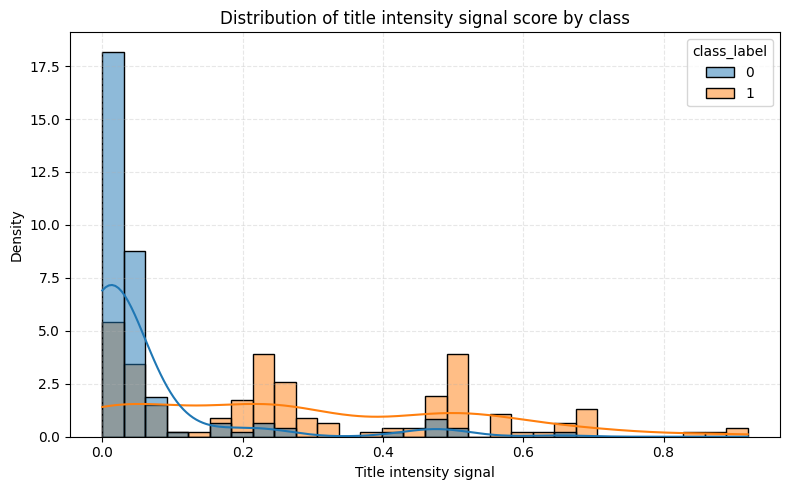

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=test_df,
    x="title_signal_score",
    hue="class_label",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of title intensity signal score by class")
plt.xlabel("Title intensity signal")
plt.ylabel("Density")

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

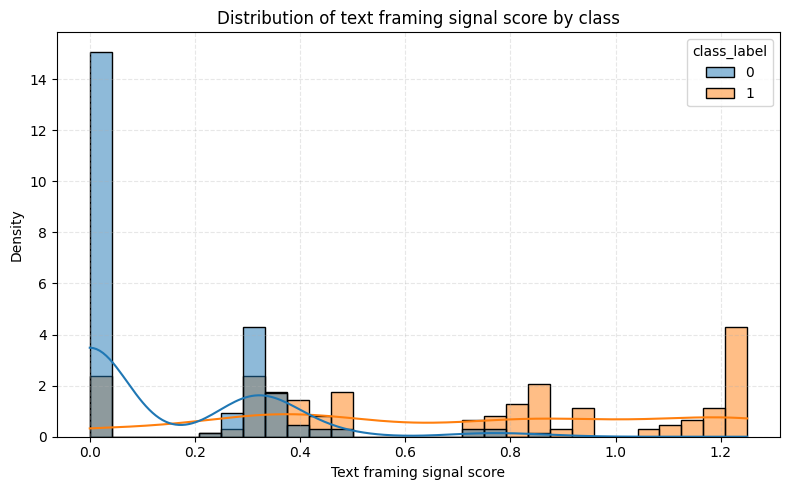

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/hssc_final_features/test_hssc_features.csv")

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="text_signal_score",
    hue="class_label",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of text framing signal score by class")
plt.xlabel("Text framing signal score")
plt.ylabel("Density")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

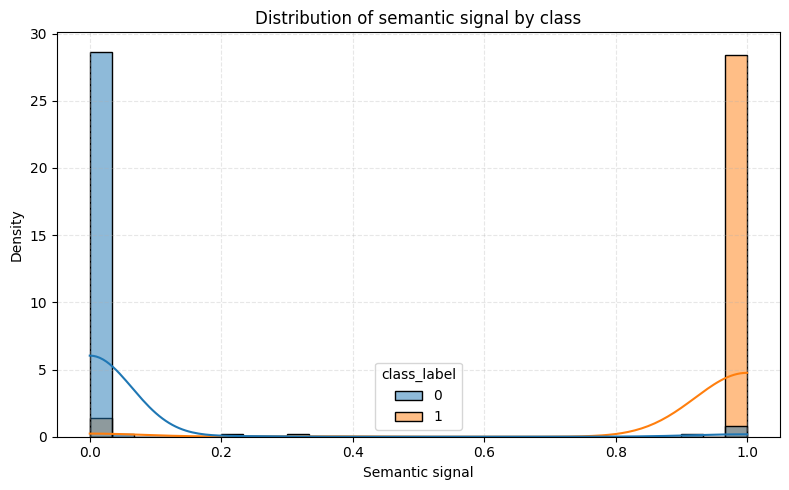

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/hssc_final_features/test_hssc_features.csv")

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="semantic_signal",
    hue="class_label",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of semantic signal by class")
plt.xlabel("Semantic signal")
plt.ylabel("Density")

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()